# Аналіз Spotify-треків

У цьому ноутбуці виконано дослідження аудіофіч Spotify-треків, аналіз популярності, кластеризацію та побудову простої моделі класифікації.

## Імпорт бібліотек

Підключаємо бібліотеки для роботи з даними, візуалізаціями та машинним навчанням.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pd.options.display.float_format = "{:.4f}".format

## Завантаження даних

Зчитуємо дані з файлу `data/dataset.csv` і прибираємо службову колонку індексу, якщо вона присутня.

In [2]:
path = Path("data/dataset.csv")

if not path.exists():
    raise FileNotFoundError(f"Файл не знайдено: {path}")

df = pd.read_csv(path, low_memory=False)
df.columns = df.columns.str.strip()

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.shape)
display(df.head())

(114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.6760,0.4610,1,-6.7460,0,0.1430,0.0322,0.0000,0.3580,0.7150,87.9170,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.4200,0.1660,1,-17.2350,1,0.0763,0.9240,0.0000,0.1010,0.2670,77.4890,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.4380,0.3590,0,-9.7340,1,0.0557,0.2100,0.0000,0.1170,0.1200,76.3320,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.2660,0.0596,0,-18.5150,1,0.0363,0.9050,0.0001,0.1320,0.1430,181.7400,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.6180,0.4430,2,-9.6810,1,0.0526,0.4690,0.0000,0.0829,0.1670,119.9490,4,acoustic


## Первинний огляд

Перевіряємо типи даних, пропуски та дублікати, щоб оцінити якість датасету перед подальшим аналізом.

In [3]:
df.info()
print()
print("Пропуски по колонках:")
print(df.isna().sum().sort_values(ascending=False))
print()
print("Кількість дублікатів:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

## Очищення та підготовка ознак

Прибираємо дублікати й пропуски, а також готуємо похідні змінні для аналізу та моделювання.

In [4]:
df = df.drop_duplicates().dropna().copy()

if "duration_ms" in df.columns:
    df["duration_min"] = df["duration_ms"] / 60000

popularity_threshold = df["popularity"].median()
df["popular_high"] = (df["popularity"] >= popularity_threshold).astype(int)

base_features = [
    "duration_min",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
]

model_cols = [c for c in base_features if c in df.columns]
cluster_cols = [c for c in [
    "danceability",
    "energy",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
] if c in df.columns]

print(df.shape)
display(df.head())

(113549, 22)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,popular_high
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.6760,0.4610,1,...,0.1430,0.0322,0.0000,0.3580,0.7150,87.9170,4,acoustic,3.8444,1
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.4200,0.1660,1,...,0.0763,0.9240,0.0000,0.1010,0.2670,77.4890,4,acoustic,2.4935,1
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.4380,0.3590,0,...,0.0557,0.2100,0.0000,0.1170,0.1200,76.3320,4,acoustic,3.5138,1
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.2660,0.0596,0,...,0.0363,0.9050,0.0001,0.1320,0.1430,181.7400,3,acoustic,3.3655,1
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.6180,0.4430,2,...,0.0526,0.4690,0.0000,0.0829,0.1670,119.9490,4,acoustic,3.3142,1


## Описова статистика

Дивимося на базові характеристики числових змінних і перевіряємо загальний масштаб значень.

In [5]:
numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
popularity,113549.0000,33.3244,22.2839,0.0000,17.0000,35.0000,50.0000,100.0000
duration_ms,113549.0000,228081.3708,106413.0985,8586.0000,174184.0000,213000.0000,261588.0000,5237295.0000
danceability,113549.0000,0.5670,0.1734,0.0000,0.4560,0.5800,0.6950,0.9850
energy,113549.0000,0.6421,0.2511,0.0000,0.4730,0.6850,0.8540,1.0000
key,113549.0000,5.3095,3.5601,0.0000,2.0000,5.0000,8.0000,11.0000
loudness,113549.0000,-8.2434,5.0114,-49.5310,-9.9980,-6.9970,-5.0010,4.5320
mode,113549.0000,0.6379,0.4806,0.0000,0.0000,1.0000,1.0000,1.0000
speechiness,113549.0000,0.0847,0.1058,0.0000,0.0359,0.0489,0.0845,0.9650
acousticness,113549.0000,0.3141,0.3319,0.0000,0.0168,0.1680,0.5960,0.9960
instrumentalness,113549.0000,0.1557,0.3092,0.0000,0.0000,0.0000,0.0487,1.0000


## Розподіл популярності та жанрів

Оцінюємо форму розподілу популярності та дивимося, які жанри представлені найчастіше.

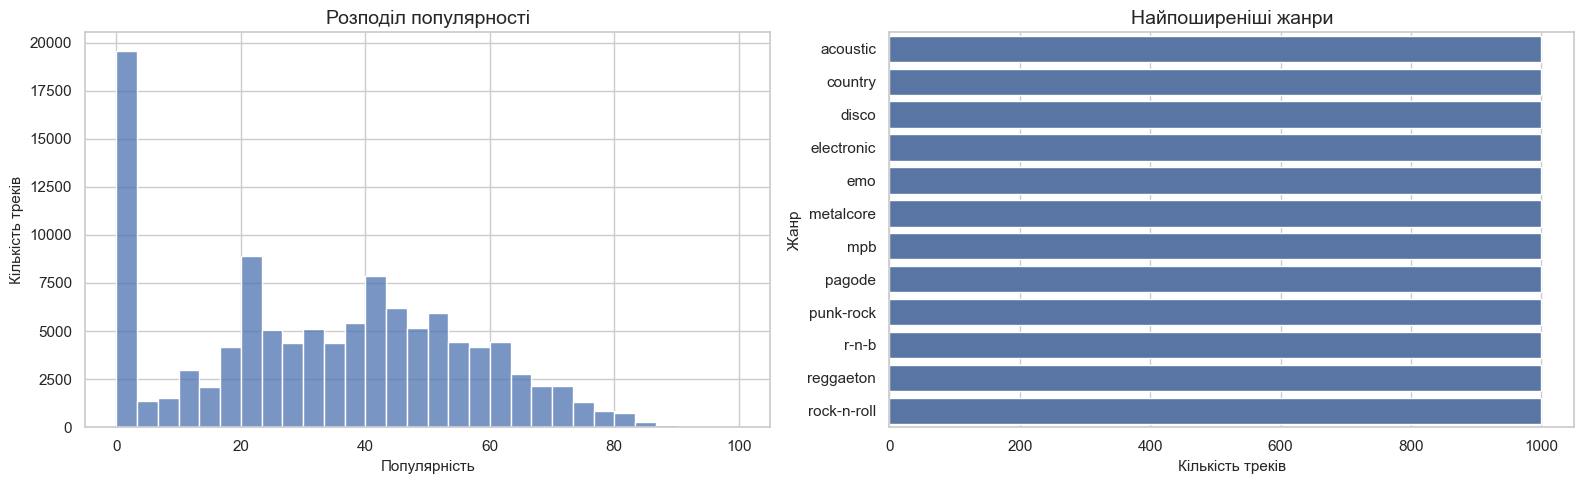

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df["popularity"], bins=30, ax=axes[0])
axes[0].set_title("Розподіл популярності")
axes[0].set_xlabel("Популярність")
axes[0].set_ylabel("Кількість треків")

top_genres = df["track_genre"].value_counts().head(12).index
genre_counts = df[df["track_genre"].isin(top_genres)]["track_genre"].value_counts().sort_values(ascending=True)
sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[1])
axes[1].set_title("Найпоширеніші жанри")
axes[1].set_xlabel("Кількість треків")
axes[1].set_ylabel("Жанр")

plt.tight_layout()
plt.show()

## Порівняння жанрів за популярністю

Порівнюємо середню популярність у найпоширеніших жанрах, щоб побачити, де треки мають кращі показники.

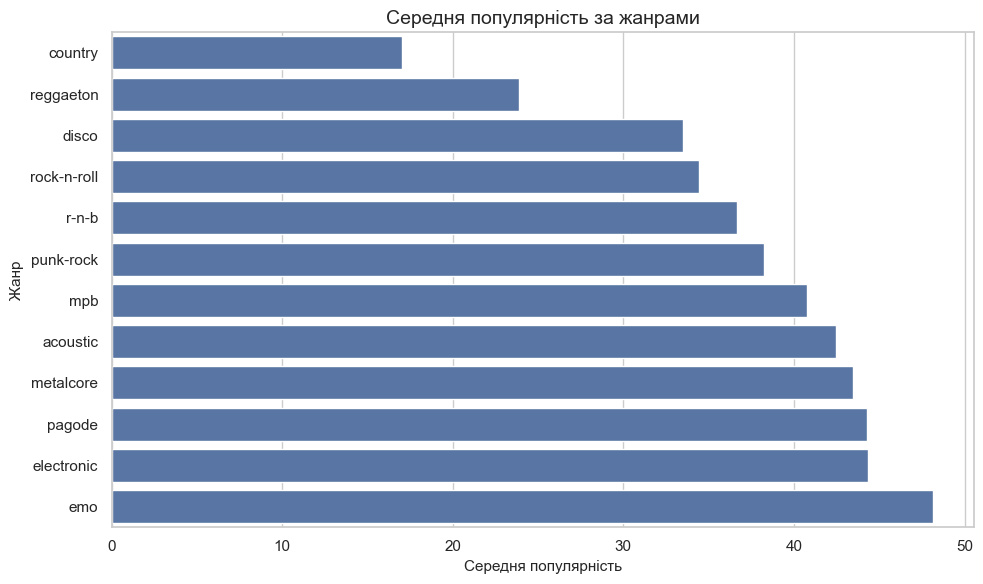

In [7]:
genre_popularity = (
    df[df["track_genre"].isin(top_genres)]
    .groupby("track_genre", as_index=False)["popularity"]
    .mean()
    .sort_values("popularity", ascending=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=genre_popularity, x="popularity", y="track_genre")
plt.title("Середня популярність за жанрами")
plt.xlabel("Середня популярність")
plt.ylabel("Жанр")
plt.tight_layout()
plt.show()

## Кореляційний аналіз

Будуємо кореляційну матрицю, щоб побачити зв’язки між аудіофічами та популярністю.

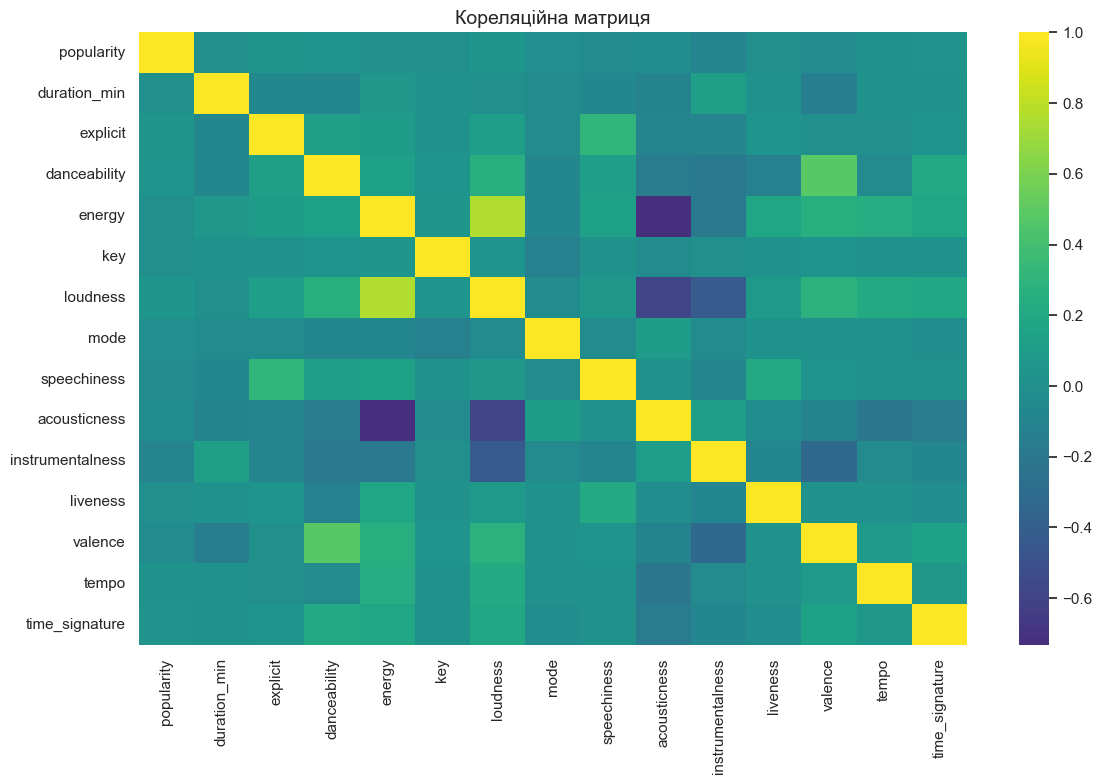

In [8]:
corr_cols = [c for c in [
    "popularity",
    "duration_min",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
] if c in df.columns]

corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="viridis", center=0)
plt.title("Кореляційна матриця")
plt.tight_layout()
plt.show()

## Оцінка кількості кластерів

Перевіряємо кілька значень k через метод ліктя та silhouette score, щоб обґрунтувати вибір кількості кластерів.

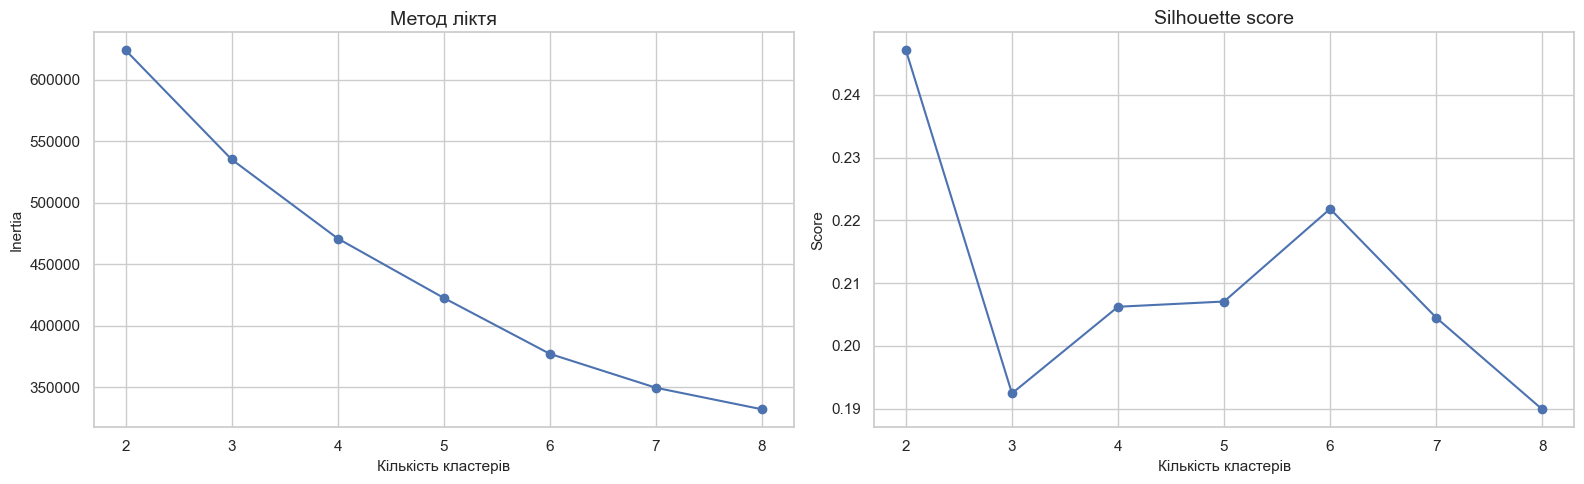

,k,inertia,silhouette
0,2,624127.7540,0.2471
1,3,535279.0457,0.1925
2,4,470998.3047,0.2062
3,5,422635.7024,0.2071
4,6,377162.1389,0.2218
5,7,349578.6397,0.2045
6,8,332045.8687,0.1899


In [9]:
cluster_data = df[cluster_cols].copy()
scaled = StandardScaler().fit_transform(cluster_data)
ks = range(2, 9)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_title("Метод ліктя")
axes[0].set_xlabel("Кількість кластерів")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(ks), silhouettes, marker="o")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Кількість кластерів")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

metrics = pd.DataFrame({"k": list(ks), "inertia": inertias, "silhouette": silhouettes})
display(metrics)

## Кластеризація та візуалізація

Будуємо фінальну кластеризацію, зменшуємо розмірність до двох компонент PCA та дивимося на профіль кожного кластера.

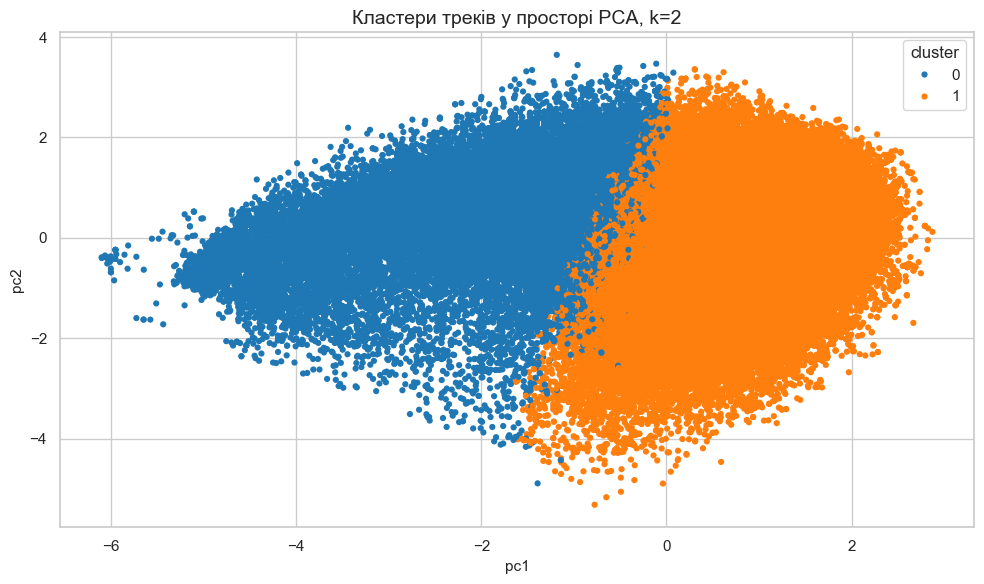

Пояснена дисперсія PCA: 0.512


,danceability,energy,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,
0,0.4820,0.3340,0.7310,0.2570,0.1840,0.3330,109.9790
1,0.6000,0.7600,0.1540,0.1170,0.2250,0.5290,126.8570


In [10]:
n_clusters = int(metrics.sort_values(["silhouette", "inertia"], ascending=[False, True]).iloc[0]["k"])

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(scaled)

cluster_view = pd.DataFrame(coords, columns=["pc1", "pc2"])
cluster_view["cluster"] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_view, x="pc1", y="pc2", hue="cluster", palette="tab10", s=20, linewidth=0)
plt.title(f"Кластери треків у просторі PCA, k={n_clusters}")
plt.tight_layout()
plt.show()

print("Пояснена дисперсія PCA:", round(pca.explained_variance_ratio_.sum(), 3))
display(df.assign(cluster=clusters).groupby("cluster")[cluster_cols].mean().round(3))

## Моделювання популярності

Перетворюємо задачу на класифікацію і порівнюємо базову логістичну регресію з випадковим лісом.

,accuracy,f1
model,,
RandomForest,0.7787,0.7889
LogisticRegression,0.5742,0.5943


              precision    recall  f1-score   support

           0       0.81      0.73      0.77     11317
           1       0.76      0.82      0.79     11393

    accuracy                           0.78     22710
   macro avg       0.78      0.78      0.78     22710
weighted avg       0.78      0.78      0.78     22710

[[8294 3023]
 [2003 9390]]


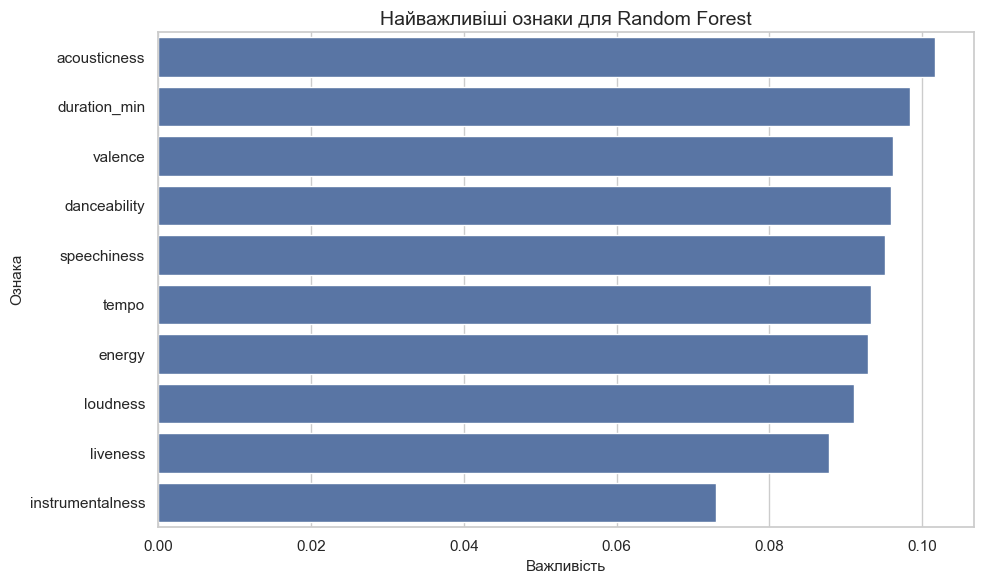

In [11]:
X = df[model_cols].copy()
y = df["popular_high"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
    ),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
    })

results = pd.DataFrame(rows).set_index("model")
display(results.sort_values("f1", ascending=False))

rf = models["RandomForest"]
rf_pred = rf.predict(X_test)
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Найважливіші ознаки для Random Forest")
plt.xlabel("Важливість")
plt.ylabel("Ознака")
plt.tight_layout()
plt.show()

## Підсумок

Акустичні характеристики треків утворюють чітку математичну структуру.

Алгоритм K-Means успішно згрупував композиції за їхнім аудіопрофілем, що виявилося об'єктивнішим за стандартні жанрові теги.

Алгоритми машинного навчання здатні класифікувати треки виключно за звуковими параметрами.

Модель Random Forest продемонструвала найвищу ефективність та точність за метрикою F1.

Оцінка важливості ознак чітко виділила ключові фізичні властивості звуку, які є визначальними для музичних композицій.